In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv("/content/Cancer dataset.csv")

# Remove unnecessary columns
df = df.drop(["id", "Unnamed: 32"], axis=1)

In [3]:
# Convert target into numbers
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with PCA components
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["diagnosis"] = y.values

In [5]:
# Display explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

# Display first 5 rows
print("\nPCA Transformed Data:")
print(pca_df.head())

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Variance Explained:
0.6324320765155944

PCA Transformed Data:
        PC1        PC2  diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1


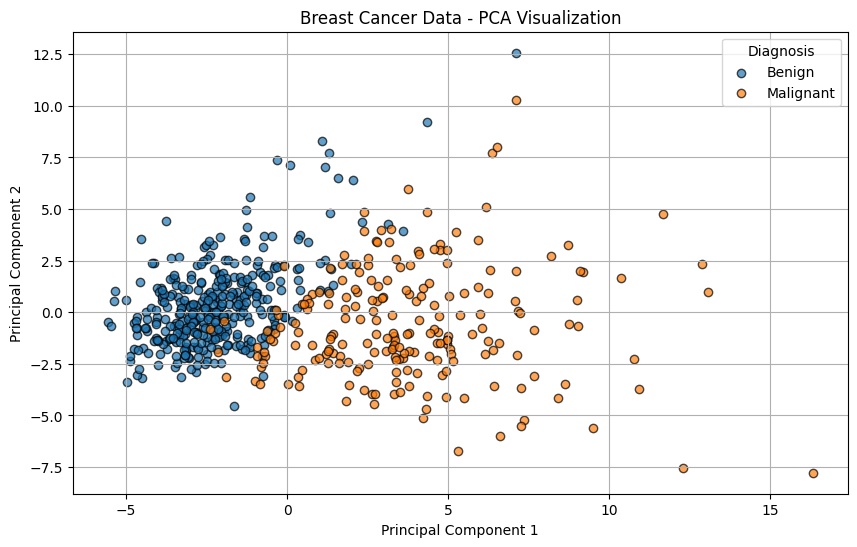

In [7]:
# Plot PCA results - Different Visualization

plt.figure(figsize=(10, 6))

for label in sorted(pca_df["diagnosis"].unique()):
    subset = pca_df[pca_df["diagnosis"] == label]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label="Malignant" if label == 1 else "Benign",
        alpha=0.7,
        edgecolors="black"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Data - PCA Visualization")
plt.legend(title="Diagnosis")
plt.grid(True)

plt.show()